In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

import networkx as nx
import folium
import osmnx as ox
from matplotlib.pyplot import gray

DEF_START = "1600 Pennsylvania Ave NW, Washington, DC 20500" # White House
DEF_END = "704 26th St NE, Washington, DC 20002" # Phelps High School

In [2]:
def geocode_location(prompt_text):
    while True:
        location = input(prompt_text)
        try:
            geo = ox.geocode(location)
            return geo, location
        except Exception:
            print("Location not found. Please query again.")

# Source: ChatGPT
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # meters
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi/2)**2 + \
        math.cos(phi1) * math.cos(phi2) * math.sin(dlambda/2)**2

    return 2 * R * math.asin(math.sqrt(a))

def loc_prompt():
    """
    :return: start and end geo locations
    """
    geo_start, loc_start = geocode_location("Please enter your starting location: ")
    geo_end, loc_end = geocode_location("Please enter your destination: ")

    print(f"Start Point: {geo_start} \'{loc_start}\'")
    print(f"End Point: {geo_end} \'{loc_end}\'")

    points = [geo_start, geo_end]
    return points

def center(points):
    """
    :param start: start address
    :param end: end address
    :return: center point and the correct radius for a plot
    """
    start_lat = points[0][0]
    start_lon = points[0][1]
    end_lat = points[1][0]
    end_lon = points[1][1]

    geo_center = (
        ( float(start_lat)+float(end_lat) ) / 2,
        ( float(start_lon)+float(end_lon) ) / 2
                 )

    # Haversine distance between locations * 1.25 for some bezels for mapping
    bezel_factor = 1.25
    geo_dist = (haversine(start_lat, start_lon, end_lat, end_lon) / 2) * bezel_factor
    # geo_dist = max(geo_dist, 1000)
    geo_dist = round(geo_dist, 2)

    return geo_center, geo_dist, start_lat, start_lon, end_lat, end_lon

In [3]:
G = ox.graph_from_place("Washington, District of Columbia, USA",        # ~ 2 minutes
                        network_type="walk")

In [4]:
# Convert to GeoDataFrames if needed
nodes, edges = ox.graph_to_gdfs(G)      # ~ 9 sec

In [5]:
# Export shapeflies ~ 30 seconds
output_dir = os.path.join(os.getcwd(), 'Network Outputs')

if os.path.exists(output_dir):
    nodes.to_file(os.path.join(output_dir, "nodes.shp"))
    edges.to_file(os.path.join(output_dir, "edges.shp"))
else:
    os.mkdir(output_dir)
    nodes.to_file(os.path.join(output_dir, "nodes.shp"))
    edges.to_file(os.path.join(output_dir, "edges.shp"))

/var/folders/mv/9l39xh61679g3fk2_5cyrrzh0000gn/T/ipykernel_3945/1114188305.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file(os.path.join(output_dir, "nodes.shp"))
/opt/anaconda3/envs/DC-Metro-Crime/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


## START HERE


In [6]:
'''
DEF_START = "1600 Pennsylvania Ave NW, Washington, DC 20500"    # White House

DEF_END = "704 26th St NE, Washington, DC 20002"                # Phelps High School
'''

'\nDEF_START = "1600 Pennsylvania Ave NW, Washington, DC 20500"    # White House\n\nDEF_END = "704 26th St NE, Washington, DC 20002"                # Phelps High School\n'

In [9]:
geo_center, geo_dist, start_lat, start_lon, end_lat, end_lon = center(loc_prompt())

print(f"Center Point: {geo_center}")
print(f"Graph Radius: {geo_dist:.2f} m") # check units?

Start Point: (38.8892122, -77.050172) 'lincoln memorial, washington dc'
End Point: (38.8976387, -77.0365528) 'the white house'
Center Point: (38.89342545, -77.0433624)
Graph Radius: 941.08 m


In [10]:
graph = ox.graph_from_point(geo_center, dist=geo_dist, network_type='walk') # runtime dep on geo_dist

In [11]:
origin_node = ox.distance.nearest_nodes(graph, start_lon, start_lat)
destination_node = ox.distance.nearest_nodes(graph, end_lon, end_lat)

In [26]:
route = nx.shortest_path(graph, origin_node, destination_node, weight = 'length', method = 'dijkstra')
route_length_meters = nx.shortest_path_length( graph,
                                               origin_node,
                                               destination_node,
                                               weight = 'length',
                                               method = 'dijkstra')

In [27]:
print(route_length_meters)

2050.3433134418497


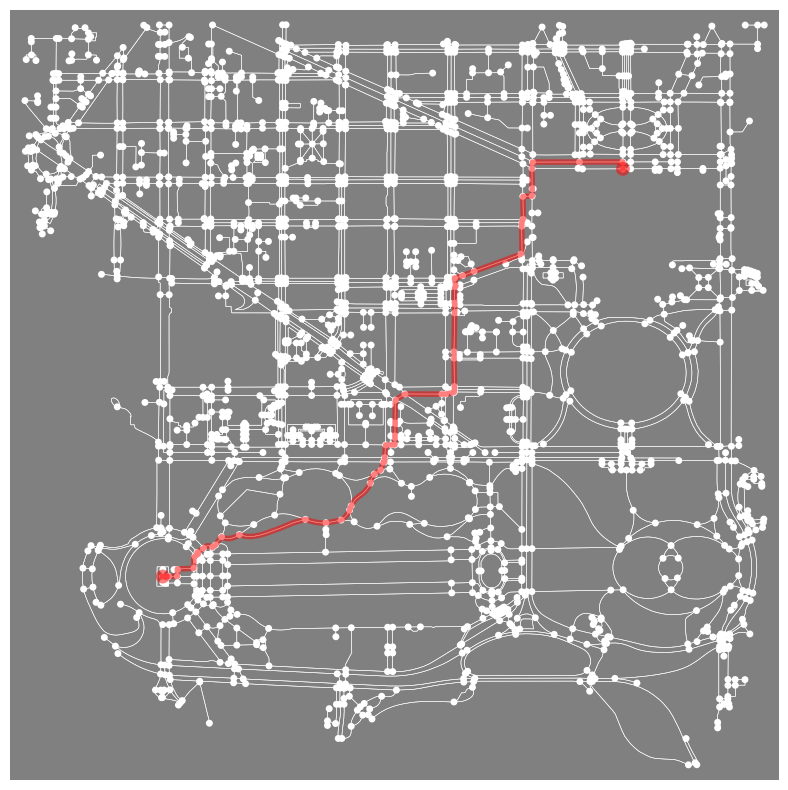

In [23]:
fig, ax = ox.plot_graph_route(graph, route,
              bgcolor='gray',
              node_color='white',
              edge_color='white',
              edge_linewidth=0.4,
              node_size=25,
              figsize=(10, 10)
              )

origin_xy = (graph.nodes[origin_node]['x'], graph.nodes[origin_node]['y'])
destination_xy = (graph.nodes[destination_node]['x'], graph.nodes[destination_node]['y'])

ax.scatter(*origin_xy, c='green', s=100, label='Origin', zorder=4)
ax.scatter(*destination_xy, c='red', s=100, label='Destination', zorder=4)
ax.legend(facecolor='white', edgecolor='black')

plt.show()

In [44]:
from folium.plugins import *

m = folium.Map(
    location = geo_center,
    zoom_start = 15

)

In [32]:
edges_gdf = ox.graph_to_gdfs(graph, nodes=False, edges=True)

In [36]:
for _, row in edges_gdf.iterrows():
    coords = [(lat, lon) for lon, lat in row['geometry'].coords]
    folium.PolyLine(coords, color = '#888888', weight = 1, opacity = 0.5).add_to(m)

In [45]:
route_coords = [
    (graph.nodes[node]['y'], graph.nodes[node]['x'])
    for node in route
]

In [52]:
ScrollZoomToggler().add_to(m)
folium.PolyLine(route_coords, color = 'red', weight = 4, opacity = 0.75).add_to(m)
folium.Marker(
    location = origin_xy,
    icon = folium.Icon(color='green', icon = 'flag', prefix='fa')
).add_to(m)
folium.Marker(
    location = destination_xy,
    icon = folium.Icon(color='red', icon = 'flag', prefix = 'fa')
).add_to(m)

m